In [1]:
import math
import random

import numpy as np
import matplotlib.pyplot as plt
from jupyter_lsp.specs import JavascriptTypescriptLanguageServer
from sympy.core import parameters
from torch.distributed.pipelining import _backward
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)

In [5]:
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [6]:
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

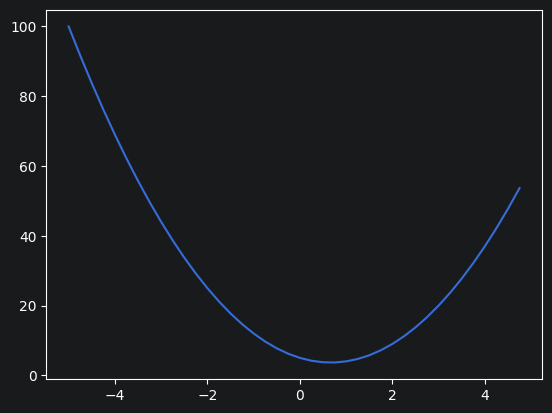

In [7]:
plt.plot(xs, ys)

In [8]:
h = 0.000001
x = 2/3
(f(x+h) - f(x)) / h

2.999378523327323e-06

In [9]:
# let's go more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [10]:
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print('d1: ', d1)
print('d2: ', d2)
print("slope: " , (d2-d1)/h)

d1:  4.0
d2:  3.999699999999999
slope:  -3.000000000010772


In [11]:
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
b += h
d2 = a*b + c

print('d1: ', d1)
print('d2: ', d2)
print("slope: " , (d2-d1)/h)

d1:  4.0
d2:  4.0002
slope:  2.0000000000042206


In [12]:
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1: ', d1)
print('d2: ', d2)
print("slope: " , (d2-d1)/h)

d1:  4.0
d2:  4.0001
slope:  0.9999999999976694


### Neural Network

In [13]:
class Value:
    def __init__(self, data, _children = (), _op='', label = ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __radd__(self, other):
        return self + other

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out =  Value(self.data + other.data, (self, other) , '+')
        def _backward():
            self.grad += 1.0 * out.grad # Multivariate Chain Rule
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out =  Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __sub__(self, other):
        return self + (-other)

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ) , f'**{other}')

        def _backward():
            self.grad += other * self.data**(other - 1) * out.grad
        out._backward = _backward

    def __truediv__(self, other):
        return self * other**-1



    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) -1 ) / (math.exp(2 * x) + 1)
        out =  Value(t , _children=(self,) , _op='tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x) , (self,) , _op='exp')

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [14]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')

In [15]:
print("a:", a)
print("b:", b)

a: Value(data=2.0)
b: Value(data=-3.0)


In [16]:
print("a+b:", a + b)
# print(a.__add__(b)) both are same

a+b: Value(data=-1.0)


In [17]:
print("a+b:", a + b)
# print("a-b:", a-b)
print("a*b:", a*b)


a+b: Value(data=-1.0)
a*b: Value(data=-6.0)


In [18]:
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0 , label='f')
L = d * f; L.label = 'L'

In [19]:
print(d)

Value(data=4.0)


In [20]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [21]:
d._op

'+'

In [22]:
print(d)

Value(data=4.0)


In [23]:
print(d._prev)

{Value(data=-6.0), Value(data=10.0)}


In [24]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                # print("nodes: ", nodes)
                # print("edges: ", edges)
                build(child)

    build(root)
    # print("%-------------------------------------------------------------%")
    # print("nodes: ", nodes)
    # print("edges: ", edges)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad ), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

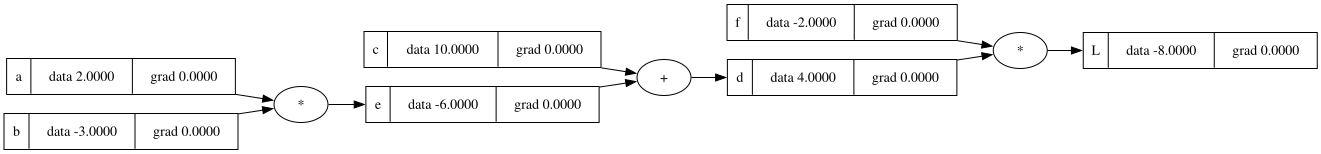

In [25]:
draw_dot(L)

# Calculations

In [26]:
"""
L = d * f
dL/dd = f = -2.0
dL/df = d = 4.0
d = c + e
dd/dc = 1.0
dd/de = 1.0
dL/ dc = dL/dd * dd/dc = f * 1.0 = f = -2.0
dL/de = dL/dd * dd/dc = f * 1.0 = f = -2.0

e = a*b
de/da = b
de/db = a
dL/da = dL/de * de/da = -2.0 * b = -2.0 * -3.0 = 6.0
dL/db = dL/de * de/db = -2.0 * a = -2.0 * 2.0 = -4.0
"""

'\nL = d * f\ndL/dd = f = -2.0\ndL/df = d = 4.0\nd = c + e\ndd/dc = 1.0\ndd/de = 1.0\ndL/ dc = dL/dd * dd/dc = f * 1.0 = f = -2.0\ndL/de = dL/dd * dd/dc = f * 1.0 = f = -2.0\n\ne = a*b\nde/da = b\nde/db = a\ndL/da = dL/de * de/da = -2.0 * b = -2.0 * -3.0 = 6.0\ndL/db = dL/de * de/db = -2.0 * a = -2.0 * 2.0 = -4.0\n'

In [27]:
L.grad = 1.0
f.grad = 4.0
d.grad = -2.0
c.grad = -2.0
e.grad = -2.0
a.grad = 6.0
b.grad = -4.0

In [28]:
# Backpropagation
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
e.data += 0.01 * e.grad
f.data += 0.01 * f.data
d.data += 0.01 * d.grad

# Forward pass
e = a*b
d = e + c
L = d * f

print(L.data)

-7.509552


In [29]:
def lol():
    h = 0.001
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0 , label='f')
    L = d * f; L.label = 'L'
    L1 = L

    a = Value(2.0 + h, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0 , label='f')
    L = d * f; L.label = 'L'
    L2 = L

    print((L2.data -  L1.data)/h)

lol()


6.000000000000227


# NN

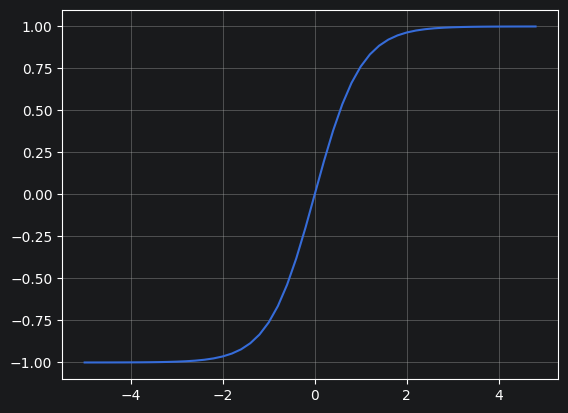

In [30]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2)), label='tanh'); plt.grid()

In [31]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1w1 + x2w2 + b
x1w1 = x1 * w1; x1w1.label = "x1*w1"
x2w2 = x2 * w2; x2w2.label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1*w1 + x2*w2"
n = x1w1x2w2 + b; n.label = "n"
o = n.tanh() ; o.label = "o"


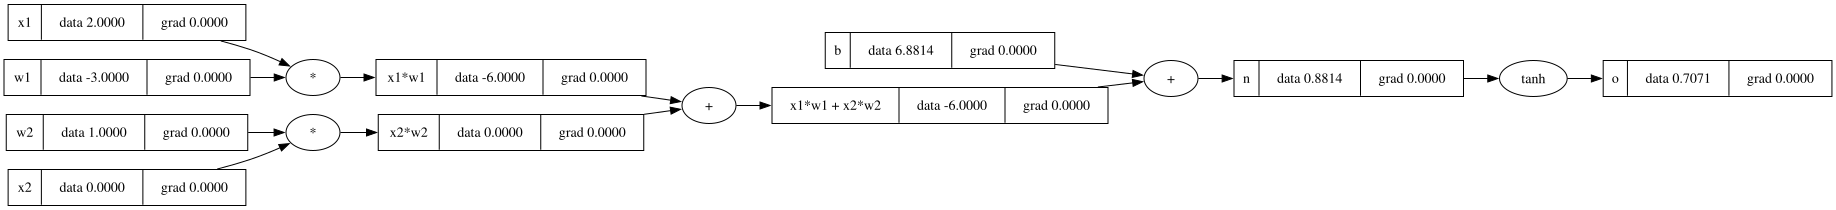

In [32]:
draw_dot(o)

In [33]:
o.grad  = 1.0
n.grad = 0.5
b.grad = 0.5
x1w1x2w2.grad = 0.5

x1w1.grad = 0.5
x2w2.grad = 0.5

x1.grad = x1w1.grad * w1.data
w1.grad = x1w1.grad * x1.data
x2.grad = x2w2.grad * x2.data
w2.grad = x2w2.grad * w2.data

In [34]:
1 - o.data ** 2

0.4999999999999999

In [35]:
"""
o = tanh(n)
do/dn = 1-tanh(n) ** 2 = 1 - o**2 = 10.5

dL/dw2 = dL/dx2w2 * dx2w2/dw2 = 0.5 * 0 = 0

"""

'\no = tanh(n)\ndo/dn = 1-tanh(n) ** 2 = 1 - o**2 = 10.5\n\ndL/dw2 = dL/dx2w2 * dx2w2/dw2 = 0.5 * 0 = 0\n\n'

In [36]:
o.grad = 1.0
o._backward()
n._backward()
b._backward() # leaf node
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()


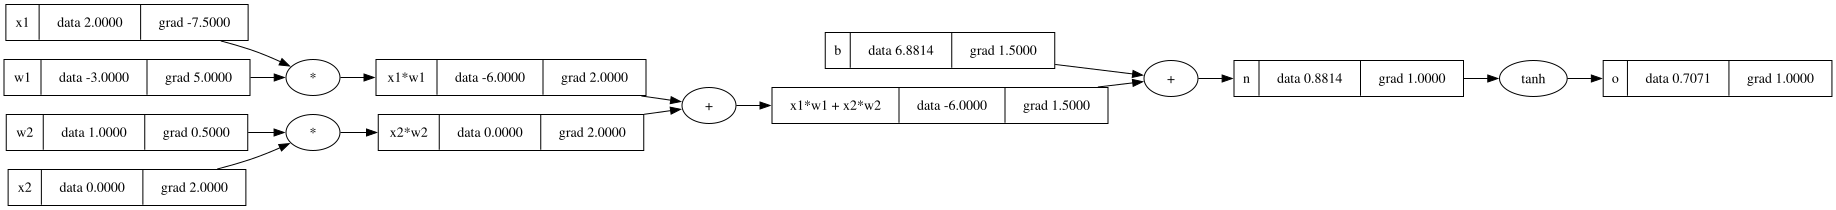

In [37]:
draw_dot(o)

# Topological Sorting

In [38]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

# Backward

In [39]:
o.backward()

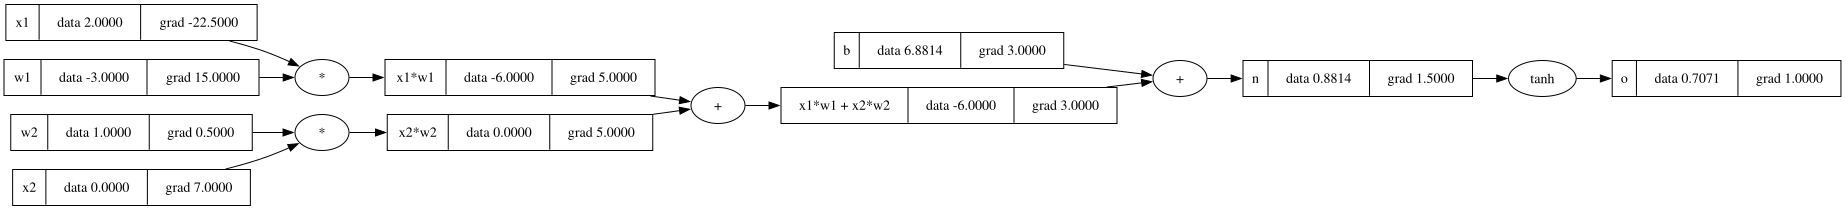

In [40]:
draw_dot(o)

# Bug

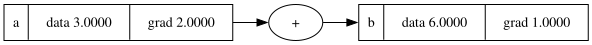

In [41]:
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

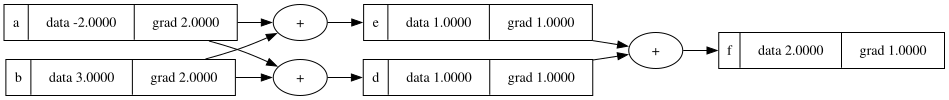

In [42]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a + b; d.label = 'd'
e = a + b; e.label = 'e'
f = d + e; f.label = 'f'

f.backward()
draw_dot(f)

# Breaking TANH

In [43]:
a = Value(-2.0, label='a')
print(a + 1)
print(a*2)

Value(data=-1.0)
Value(data=-4.0)


In [44]:
print(2*a)

Value(data=-4.0)


In [45]:
class Value:
    def __init__(self, data, _children = (), _op='', label = ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __radd__(self, other):
        return self + other

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out =  Value(self.data + other.data, (self, other) , '+')
        def _backward():
            self.grad += 1.0 * out.grad # Multivariate Chain Rule
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out =  Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __sub__(self, other):
        return self + (-other)

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ) , f'**{other}')

        def _backward():
            self.grad += other * self.data**(other - 1) * out.grad
        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self * other**-1


    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) -1 ) / (math.exp(2 * x) + 1)
        out =  Value(t , _children=(self,) , _op='tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x) , (self,) , _op='exp')

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

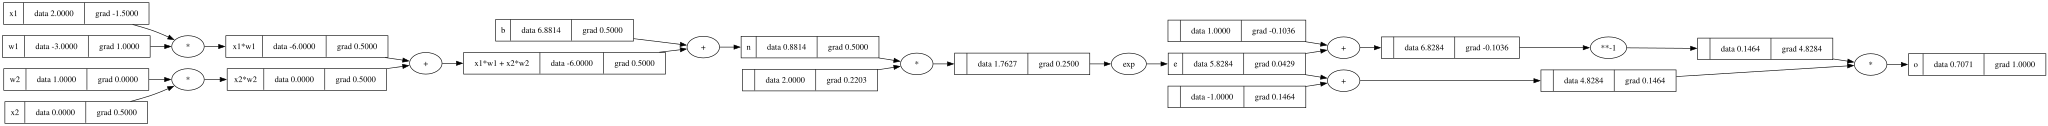

In [46]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1w1 + x2w2 + b
x1w1 = x1 * w1; x1w1.label = "x1*w1"
x2w2 = x2 * w2; x2w2.label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1*w1 + x2*w2"
n = x1w1x2w2 + b; n.label = "n"
# -----------------
e = (2*n).exp(); e.label = "e"
o = (e - 1) / (e + 1) ; o.label = "o"
# -----------------
o.backward()
draw_dot(o)

# Using PyTorch

In [47]:
import torch

In [48]:
x1 = torch.Tensor([2.0]).double();  x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print("--------")
print('x2' , x2.grad.item())
print('w2' , w2.grad.item())
print('x1' , x1.grad.item())
print('w1' , w1.grad.item())

0.7071066904050358
--------
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


# NN from scratch

In [49]:
class Value:
    def __init__(self, data, _children = (), _op='', label = ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __radd__(self, other):
        return self + other

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out =  Value(self.data + other.data, (self, other) , '+')
        def _backward():
            self.grad += 1.0 * out.grad # Multivariate Chain Rule
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out =  Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __sub__(self, other):
        return self + (-other)

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ) , f'**{other}')

        def _backward():
            self.grad += other * self.data**(other - 1) * out.grad
        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self * other**-1


    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) -1 ) / (math.exp(2 * x) + 1)
        out =  Value(t , _children=(self,) , _op='tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x) , (self,) , _op='exp')

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [50]:
import random
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    def __call__(self, x):
        # w*x  + b
        act = sum((wi * xi for wi , xi in zip(self.w, x)),  self.b)
        out = act.tanh()
        return out
    def parameters(self):
        return self.w + [self.b]
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    def parameters(self):
        params = []
        for neuron in self.neurons:
            pa = neuron.parameters()
            params.extend(pa)
        return params

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i] , sz[i+1]) for i in range(len(nouts))]
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]



In [51]:
x = [2.0 , 3.0 , 4.0]
n = Neuron(3)
n(x)

Value(data=0.9856077459894079)

In [52]:
x = [2.0 , 3.0 , 4.0]
n = Layer(3,3)
n(x)

[Value(data=0.9999828107630341),
 Value(data=-0.9986089360022095),
 Value(data=0.8881130766880112)]

In [53]:
x = [2.0 , 3.0 , -1.0]
n = MLP(3 , [4,4,1])
n(x)

Value(data=-0.7033997873602296)

In [103]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0 , -1.0, -1.0 , 1.0] # Desired targets

In [54]:
y_pred = [n(x) for x in xs]
y_pred

[Value(data=-0.7033997873602296),
 Value(data=-0.8021975367633859),
 Value(data=-0.7442464050868018),
 Value(data=-0.8401420940968993)]

In [55]:
[(yout - ygt)**2 for ygt, yout in zip(ys, y_pred)]

[Value(data=2.9015708355788754),
 Value(data=0.039125814462472076),
 Value(data=0.06540990131102425),
 Value(data=3.386122926467322)]

In [56]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, y_pred))
loss

Value(data=6.3922294778196935)

In [57]:
loss.backward()

In [58]:
len(n.parameters())

41

In [59]:
n.parameters()

[Value(data=0.9646004705361224),
 Value(data=0.1532077545218824),
 Value(data=-0.16591124188771),
 Value(data=-0.48052342634953704),
 Value(data=0.8425027848844371),
 Value(data=0.5342446681160185),
 Value(data=0.24495113605161012),
 Value(data=0.6191241896632858),
 Value(data=-0.2503323202434058),
 Value(data=0.841018753682421),
 Value(data=0.5515055979011734),
 Value(data=-0.7872378531655277),
 Value(data=0.5432514334966914),
 Value(data=0.05482056681789782),
 Value(data=-0.14193984428069517),
 Value(data=0.5908541072783111),
 Value(data=0.5607890609723505),
 Value(data=-0.8627794395424702),
 Value(data=0.3995113372082413),
 Value(data=0.8184640675410808),
 Value(data=0.05167590222842211),
 Value(data=0.14723849532722566),
 Value(data=0.9797233206467033),
 Value(data=-0.6846956224279321),
 Value(data=-0.606246078132956),
 Value(data=-0.24118301760199068),
 Value(data=0.5641124535706854),
 Value(data=-0.5930185498007707),
 Value(data=0.48081725603835146),
 Value(data=0.050017780880599

In [60]:
n.layers[0].neurons[0].w[0].grad

-0.09557151844608065

In [61]:
#draw_dot(n(x))

In [62]:
[random.uniform(-1,1) for _ in range(5)]

[-0.5066629185993714,
 0.7602825234672883,
 -0.2988806405858231,
 -0.3500127512101836,
 -0.22368735203721624]

In [63]:
w = [Value(random.uniform(-1,1)) for _ in range(3)]
w

[Value(data=-0.00029688412922213026),
 Value(data=0.859181453351562),
 Value(data=0.6630128598269192)]

In [64]:
x = [2.0 , 3.0 , 4.0]

In [65]:
list(zip(w,x))

[(Value(data=-0.00029688412922213026), 2.0),
 (Value(data=0.859181453351562), 3.0),
 (Value(data=0.6630128598269192), 4.0)]

In [66]:
# draw_dot(loss)

In [67]:
n.layers[0].neurons[0].w[0].grad

-0.09557151844608065

In [68]:
n.layers[0].neurons[0].w[0].data

0.9646004705361224

In [69]:
for p in n.parameters():
    p.data += -0.01 * p.grad

In [70]:
n.layers[0].neurons[0].w[0].data

0.9655561857205832

In [91]:
# Forward Pass
y_pred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, y_pred))
loss

Value(data=3.442019483092623)

In [92]:
# Backward Pass
loss.backward()

In [93]:
# Update
for p in n.parameters():
    p.data += -0.01 * p.grad

In [94]:
# Go to forward pass

In [95]:
# Forward pass -> Backward pass -> Update ---------
#    ^                                            |
#    |---------------------------------------------

In [119]:
# Inputs
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0 , -1.0, -1.0 , 1.0] # Desired targets

In [120]:
# Neural Network
n = MLP(3 , [4,4,1])

In [121]:
for k in range(20):
    # Forward pass
    y_pred = [n(x) for x in xs]
    print( f"For Epoch: {k+1}" , y_pred)
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, y_pred))
    # Backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()
    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(f"Epoch {k + 1} : | Loss : {loss.data:.4f}")


For Epoch: 1 [Value(data=-0.3556559544128884), Value(data=-0.41203988138687564), Value(data=-0.41070739657161254), Value(data=-0.29188236038088133)]
Epoch 1 : | Loss : 4.1997
For Epoch: 2 [Value(data=0.35023863088068136), Value(data=-0.27161049895126643), Value(data=0.11468870789098251), Value(data=0.35021582182180816)]
Epoch 2 : | Loss : 2.6175
For Epoch: 3 [Value(data=0.31195398134888336), Value(data=-0.7065874933897658), Value(data=-0.17987921668199217), Value(data=0.19700462441145775)]
Epoch 3 : | Loss : 1.8769
For Epoch: 4 [Value(data=0.58128992147185), Value(data=-0.7147705339447474), Value(data=-0.09468722370328271), Value(data=0.4595570947724832)]
Epoch 4 : | Loss : 1.3683
For Epoch: 5 [Value(data=0.5727327267210314), Value(data=-0.8228803409330082), Value(data=-0.39021504725637723), Value(data=0.40716044440018967)]
Epoch 5 : | Loss : 0.9372
For Epoch: 6 [Value(data=0.6927646779638862), Value(data=-0.8416315645207529), Value(data=-0.44804449988228606), Value(data=0.549306536860

In [122]:
y_pred

[Value(data=0.9120214206841843),
 Value(data=-0.9441131557320803),
 Value(data=-0.8645455813779072),
 Value(data=0.8517697908332628)]